<a href="https://colab.research.google.com/github/justin3joseph/Ai-Ml_CNN-tutorials/blob/main/gec_cnn_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np


In [5]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train.shape

(50000, 32, 32, 3)

In [6]:
x_test.shape

(10000, 32, 32, 3)

In [7]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [8]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
classes[9]

'truck'

In [9]:
def plot_sample(x,y,index):
    plt.figure(figsize= (10,2))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index]])

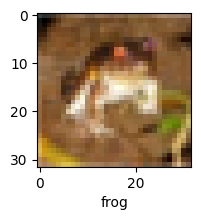

In [10]:
plot_sample(x_train, y_train, 0)

In [11]:
x_train = x_train/255
x_test = x_test/255

In [12]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='sigmoid')
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(x_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 125s 80ms/step - accuracy: 0.3553 - loss: 1.8099
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 125s 80ms/step - accuracy: 0.4279 - loss: 1.6221
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.4558 - loss: 1.5390
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 125s 80ms/step - accuracy: 0.4807 - loss: 1.4783
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 81ms/step - accuracy: 0.4975 - loss: 1.4296


In [13]:
ann.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.4468 - loss: 1.5538


[1.5537652969360352, 0.44679999351501465]

In [14]:
cnn = models.Sequential([

        ##cnn
        layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        ##dense
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

cnn.fit(x_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 49ms/step - accuracy: 0.4365 - loss: 1.5464
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 46ms/step - accuracy: 0.5887 - loss: 1.1634
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.6417 - loss: 1.0144
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.6819 - loss: 0.9133
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 46ms/step - accuracy: 0.7093 - loss: 0.8323


In [16]:
cnn.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6815 - loss: 0.9084


[0.9084179401397705, 0.6815000176429749]

In [29]:
y_pred = cnn.predict(x_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


array([[3.40269436e-03, 1.49925868e-03, 7.73810595e-03, 6.69577062e-01,
        2.32544355e-03, 1.65197372e-01, 1.30701840e-01, 2.39222520e-03,
        1.65855698e-02, 5.80384803e-04],
       [9.81392264e-02, 4.95814756e-02, 9.22660838e-05, 7.49171068e-06,
        1.60889194e-05, 8.90516105e-07, 1.22730182e-06, 3.20764229e-06,
        8.51913571e-01, 2.44502851e-04],
       [9.93634015e-02, 5.62348887e-02, 3.46010760e-03, 2.91448529e-03,
        5.10291720e-04, 3.89822730e-04, 1.09805696e-04, 3.66875029e-04,
        8.21131647e-01, 1.55186001e-02],
       [7.90800393e-01, 9.96711897e-04, 1.19353466e-01, 1.00277523e-02,
        4.18817764e-03, 6.57982018e-04, 1.58790452e-03, 1.03759761e-04,
        7.19706193e-02, 3.13156197e-04],
       [2.73701571e-05, 9.41120106e-06, 4.35124338e-02, 1.52044399e-02,
        5.51491618e-01, 1.73261680e-03, 3.87865961e-01, 7.13623231e-05,
        7.70745755e-05, 7.75475928e-06]], dtype=float32)

In [34]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:10]

[np.int64(3),
 np.int64(8),
 np.int64(8),
 np.int64(0),
 np.int64(4),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(3),
 np.int64(1)]

In [33]:
y_test = y_test.reshape(-1,)
y_test[:10]

array([3, 8, 8, 0, 6, 6, 1, 6, 3, 1], dtype=uint8)

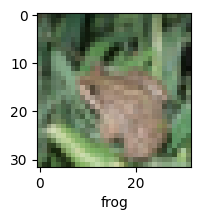

In [32]:
plot_sample(x_test, y_test,4)

In [31]:
classes[y_classes[4]]

'deer'